# Project card

**The paper:** 

> Kennedy SR, Schultz EM, Chappell TM, Kohrn B, Knowels GM, Herr AJ.

> **Volatility of Mutator Phenotypes at Single Cell Resolution.** 

> PLoS Genet. 2015 Apr 13;11(4):e1005151. 

> doi: 10.1371/journal.pgen.1005151. PMID: 25868109; PMCID: PMC4395103.

**The data object:**

> S2_Dataset.xlsx

> Novel mutations count per cell division for 8 lineages of mutator yeast deficient in DNA polymerase εproofread-
ing and base-base mismatch repair.

> 85 cell divisions across all lineages and a total of 233 novel mutations across all cell divisions.

**The random variable chosen:**

> X = k; Novel mutations count per cell division

**What the paper does:**

> Models mutation rate in mutator phenotypes of yeast. It counts the number of mutations in each cell division and fits it to a 2-Poisson model.

**The generative model proposed:**

***1-Poisson Model***

$$\mathrm{Prob}(\mathrm{X} = \mathbf{k}) = \frac{\lambda^{\mathbf{k}} \mathrm{e}^{-\lambda}}{\mathbf{k}\,!}$$

***2-Poisson Model***

https://link.springer.com/rwe/10.1007/978-0-387-39940-9_920

$$\mathrm{Prob}(\mathrm{X} = \mathbf{k}) = \pi \frac{\lambda_{low}^{\mathbf{k}} \mathrm{e}^{-\lambda_{low}}}{\mathbf{k}\,!} + (1 - \pi) \frac{\lambda_{high}^{\mathbf{k}} \mathrm{e}^{-\lambda_{high}}}{\mathbf{k}\,!} \quad [0 \le \alpha \le 1]$$

**Parameters and assumptions:**

***1-Poisson***

*Assumptions:*

> Novel mutations occur independently of each other

> The rate at which new mutations occur is constant over time

> The mean and the variance of the distribution are equal.

*Parameters:*
    
> $λ$, the expected number of novel mutations per cell division.

***2-Poisson***

*Assumptions:*

> Dividing cells have one of two distinct mutator states

> Each mutator state follows its own Poisson distribution of novel mutation counts with its own constant rate

> No memory between cell divisions

> One set of parameters for all lineages

*Parameters:*

> $λ_{low}$, the expected number of novel mutations per cell division in the low mutator state

> $λ_{high}$, the expected number of novel mutations per cell division in the high mutator state

> $π$, the probability that a individual cell division assumes the low or high mutator state

**The forward simulation:**

> Monte-Carlo simulation

**The parameterization/fitting:**

> Grid search to find parameters for 1 poisson

> Grid search to find parameters for 2 poisson

**What/if the model adds to the paper:**

 >It confirms that 2 poisson is a better fit for the data than 1 poisson

 > The parameters obtained using 2 poisson model are close to the reported values 

**Model limitations/how it breaks:**
> 1 poisson variance is much higher than the mean. its overdispersed

> The Poisson assumptions may not be perfectly satisfied biologically: mutation events may not be completely independent and mutation rates may vary between divisions. In addition, the mixture model does not prove that exactly two discrete biological populations exist; it is a simplified mechanistic model that explains the observed heterogeneity. Therefore, the estimated parameters should be interpreted as model-based estimates rather than exact biological quantities.

---

# Libraries 

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

# Functions

In [ ]:
def mean(counts):
    """The mean of a list of counts."""
    return sum(counts) / len(counts)

def std_dev(counts):
    """The standard deviation of a list of counts."""
    m = mean(counts)
    total = 0.0
    for x in counts:
        total = total + (x - m) ** 2
    return math.sqrt(total / len(counts))

def factorial(x):
    """x! as a product, 0! = 1."""
    total = 1
    for k in range(1, x + 1):
        total = total * k
    return total

def poisson(x, theta):
    """p(x | theta) = theta^x e^(-theta) / x!  the probability of x counts in a cell at rate theta."""
    return theta ** x * math.exp(-theta) / factorial(x)

def two_poisson(x, pi, lam_low, lam_high):
    return (pi * poisson(x, lam_low)) + ((1-pi) * poisson(x, lam_high))

def likelihood(counts, theta):
    """L(theta) = p(x | theta) = the product over cells of p(x_i | theta)."""
    total = 1.0
    for x in counts:
        total = total * poisson(x, theta)
    return total

def nll(counts, theta):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    total = 0.0
    for x in counts:
        total = total - math.log(poisson(x, theta))
    return total

def position_of_min(values):
    """The index of the smallest entry: the position, not the value."""
    best = 0
    for j in range(len(values)):
        if values[j] < values[best]:
            best = j
    return best

def nll_mix_poisson(parameters, counts):
    """NLL(theta) = - the sum over cells of ln p(x_i | theta)."""
    lam_low, lam_high, pi = parameters[0], parameters[1], parameters[2]
    total = 0.0
    for x in counts:
        prob = max(pi * poisson(x, lam_low) + (1 - pi) * poisson(x, lam_high), 1e-10)  # Avoid log(0)
        total = total - math.log(prob)
    return total

def fit_2_poisson(counts, mu_low_candidates, mu_high_candidates, pi_candidates):
    flag = True
    best_scores_pi = [None] * len(pi_candidates)
    best_scores_mu_low = [None] * len(mu_low_candidates)
    best_scores_mu_high = [None] * len(mu_high_candidates)
    scores = []
    for i, pi in enumerate(pi_candidates):
        for j, mu_low in enumerate(mu_low_candidates):
            for k, mu_high in enumerate(mu_high_candidates):
                total = 0
                for m in range(len(lineages)):
                    genome_size = genome_size_lineages[m]
                    total += nll_mix_poisson([(mu_low*10**(-7)) * genome_size, (mu_high*10**(-7)) * genome_size, pi], lineages[m])
                nll_mix_poisson_score = total
                scores.append(nll_mix_poisson_score)
                if best_scores_pi[i] is None or nll_mix_poisson_score < best_scores_pi[i]:
                    best_scores_pi[i] = nll_mix_poisson_score
                if best_scores_mu_low[j] is None or nll_mix_poisson_score < best_scores_mu_low[j]:
                    best_scores_mu_low[j] = nll_mix_poisson_score
                if best_scores_mu_high[k] is None or nll_mix_poisson_score < best_scores_mu_high[k]:
                    best_scores_mu_high[k] = nll_mix_poisson_score

                if flag:
                    minimum = nll_mix_poisson_score
                    mu_low_hat = mu_low
                    mu_high_hat = mu_high
                    pi_hat = pi
                    flag = False
                    
                elif nll_mix_poisson_score < minimum:
                    minimum = nll_mix_poisson_score
                    mu_low_hat = mu_low
                    mu_high_hat = mu_high
                    pi_hat = pi
                    
    return (scores, [best_scores_mu_low, best_scores_mu_high, best_scores_pi], [round(mu_low_hat, 3), round(mu_high_hat, 3), round(pi_hat, 3)])

A_LCG = 1664525
C_LCG = 1013904223
M_LCG = 2 ** 32
seed = 100

def lcg(state, a, c, m):
    """The next state of a linear congruential generator: s_{i+1} = (a * s_i + c) mod m."""
    return (a * state + c) % m

def uniforms(k, seed):
    """A list of k numbers on [0, 1): the generator run k times from the seed, each state divided by m."""
    out = [0.0] * k
    state = seed
    for i in range(k):
        state = lcg(state, A_LCG, C_LCG, M_LCG)
        out[i] = state / M_LCG
    return out

def choose(r, probs):
    """The outcome k whose slice of [0, 1) contains r, the slices laid end to end in order. Returns k as a position in probs, from 0."""
    running = 0.0
    for k in range(len(probs)):
        running = running + probs[k]
        if r < running:
            return k
    return len(probs) - 1

def fraction_zero(counts):
    empty = 0
    for c in counts:
        if c == 0:
            empty = empty + 1
    return empty / len(counts)

def simulate_count_oneP(lam, state):
    state = lcg(state, A_LCG, C_LCG, M_LCG)
    r = state/M_LCG
    total = poisson(0, lam)
    k = 0
    while r > total:
        k += 1
        total = total + poisson(k, lam)
    return k, state

def experiment_oneP(lam, cell_divisions, state):
    simulated_counts = [0] * cell_divisions
   
    for i in range(len(simulated_counts)):
        sim_count, state = simulate_count_oneP(lam, state)
        simulated_counts[i] = (sim_count)
        
    return simulated_counts, state

def simulate_count_twoP(pi, lam_low, lam_high, state):
    state = lcg(state, A_LCG, C_LCG, M_LCG)
    r = state/M_LCG
    
    lam = lam_low if r < pi else lam_high

    return simulate_count_oneP(lam, state)

def experiment_twoP(pi, lam_low, lam_high, cell_divisions, state):
    simulated_counts = [0] * cell_divisions
   
    for i in range(len(simulated_counts)):
        sim_count, state = simulate_count_twoP(pi, lam_low, lam_high, state)
        simulated_counts[i] = (sim_count)
        
    return simulated_counts, state

def param_interval(param_candidates, scores_nll_, position_of_min_nll):
    param_hat = param_candidates[position_of_min_nll]
    low = high = param_hat

    for j in range(len(param_candidates)):
        if scores_nll_[j] <= scores_nll_[position_of_min_nll] + 0.5:
            if param_candidates[j] < low:
                low = param_candidates[j]
            elif param_candidates[j] > high:
                high = param_candidates[j]

    return round(low, 3), round(high, 3)

# Reported Values

In [3]:
rprt_one_poisson_lambda = 2.652
rprt_two_poisson_lam_low = 0.402
rprt_two_poisson_lam_high = 3.897
rprt_two_poisson_pi = 0.35

sample_size = 85 # Number of samples
genome_size = int(1.02E+07)
genome_size_lineages = [10926041,10034503,10099122,10889177,11040018,9684038,10209723,10826564]

# Read Files

In [4]:
df = pd.read_excel("data/mutation_counts.xlsx", header=0, skiprows=[1], index_col=0)
df = df.replace(r"^\s*$", np.nan, regex=True)
df = df.astype(float)

lineages = [list(df[column].dropna().astype(int)) for column in df.columns]
counts = [int(y) for x in lineages for y in x]

print("Data Matrix:")
print(df,"\n")
print("Lineage Cell Division Counts:")
print("\n".join(str(lin) for lin in lineages), "\n")

Data Matrix:
           B    C    D     E   F*   G1   G2    H
Lineage                                         
3        0.0  3.0  2.0   2.0  3.0  1.0  NaN  7.0
4        2.0  7.0  2.0   3.0  7.0  1.0  NaN  0.0
5        0.0  6.0  0.0   1.0  1.0  0.0  7.0  2.0
6        3.0  0.0  3.0   6.0  3.0  0.0  6.0  0.0
7        2.0  0.0  0.0   0.0  2.0  3.0  0.0  4.0
8        4.0  2.0  0.0   0.0  NaN  6.0  5.0  3.0
9        1.0  3.0  1.0   0.0  NaN  4.0  0.0  4.0
10       3.0  4.0  1.0   8.0  0.0  5.0  NaN  1.0
11       4.0  4.0  4.0   0.0  5.0  3.0  NaN  4.0
12       NaN  6.0  5.0  10.0  2.0  5.0  NaN  1.0
13       NaN  5.0  3.0   NaN  3.0  4.0  NaN  1.0
14       NaN  1.0  0.0   NaN  1.0  NaN  NaN  3.0
15       NaN  0.0  9.0   NaN  NaN  NaN  NaN  NaN
16       NaN  NaN  4.0   NaN  NaN  NaN  NaN  NaN
17       NaN  NaN  2.0   NaN  NaN  NaN  NaN  NaN 

Lineage Cell Division Counts:
[0, 2, 0, 3, 2, 4, 1, 3, 4]
[3, 7, 6, 0, 0, 2, 3, 4, 4, 6, 5, 1, 0]
[2, 2, 0, 3, 0, 0, 1, 1, 4, 5, 3, 0, 9, 4, 2]
[2, 3, 1

# Summary Statistics

Mean: 2.7411764705882353 mutations/cell division
Mean: 2.6874279123414073e-07 mutations/cell division/bp for average genome size of 10200000
Standard Deviation: 2.3919125558306864 (mutations/cell division)
Variance: 5.721245674740486 (mutations/cell division)²
Number of zeros: 20
Variance is higher than mean, thus overdispersed


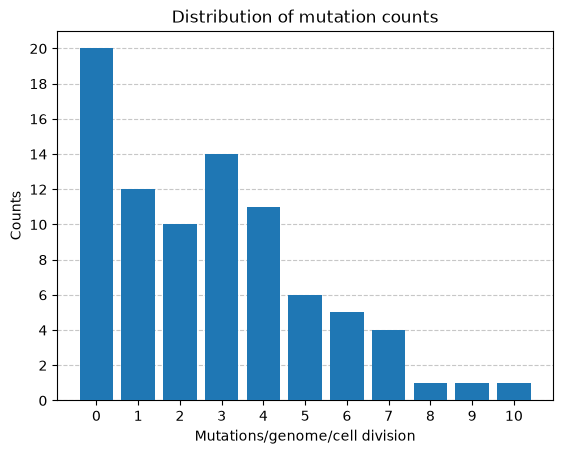

In [5]:
max_mutation_count = max(counts)
mutation_counts = [0] * (max_mutation_count + 1)

for count in counts:
    mutation_counts[count] += 1 

mean_count = mean(counts)
sigma = std_dev(counts)
sample_variance = sigma ** 2
sample_zeros = counts.count(0)
mutation_rate = mean_count/genome_size
# mutation_prob =  [ mutation_count/sum(mutation_counts) for mutation_count in mutation_counts ]

fig, ax = plt.subplots()
ax.bar(range(len(mutation_counts)), mutation_counts, zorder=3)
ax.set_xlabel("Mutations/genome/cell division")
ax.set_ylabel("Counts")
ax.set_xticks(range(0,11))
ax.set_yticks(range(0,22,2))
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.set_title("Distribution of mutation counts")

print(f"Mean: {mean_count} mutations/cell division")
print(f"Mean: {mutation_rate} mutations/cell division/bp for average genome size of {genome_size}")
print(f"Standard Deviation: {sigma} (mutations/cell division)")
print(f"Variance: {sample_variance} (mutations/cell division)²")
print(f"Number of zeros: {sample_zeros}")
print("Variance is higher than mean, thus overdispersed")

plt.show()

# Models

## 1-Poisson Model

### Forwards Simulation - Monte-Carlo Simulation

Avg. σ² (Simulation): 2.6401533746976447 (mutations/cell division)²     
σ² (Reported Data): 5.721245674740486 (mutations/cell division)²
Avg. Zero Count (Simulation) 6.29 
Zero Count (Reported Data) 20


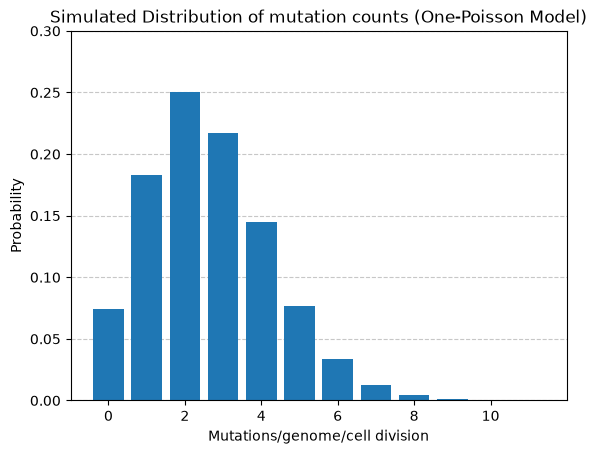

In [6]:
state = seed

simulated_runs_oneP = []
sim_oneP_devs = []
sim_oneP_zeros = []
sim_oneP_sums = []

for i in range(100):
    simulated_counts, state = experiment_oneP(rprt_one_poisson_lambda, sample_size, state)
    simulated_runs_oneP.append(simulated_counts)
    sim_oneP_devs.append(std_dev(simulated_counts))
    sim_oneP_zeros.append(fraction_zero(simulated_counts) * 85)
    

print(f"Avg. σ² (Simulation): {mean(sim_oneP_devs) ** 2} (mutations/cell division)² \
    \nσ² (Reported Data): {sample_variance} (mutations/cell division)²")
print(f"Avg. Zero Count (Simulation) {mean(sim_oneP_zeros)} \nZero Count (Reported Data) {sample_zeros}")

fig, ax = plt.subplots()
simulated_runs_oneP_flat = [y for x in simulated_runs_oneP for y in x]

simulated_oneP_mutation_counts = [0] * (max(simulated_runs_oneP_flat) + 1)


for count in simulated_runs_oneP_flat:
    simulated_oneP_mutation_counts[count] += 1 

simulated_oneP_mutation_probs = [x/sum(simulated_oneP_mutation_counts) for x in simulated_oneP_mutation_counts]

ax.bar(range(len(simulated_oneP_mutation_probs)), simulated_oneP_mutation_probs, zorder=2)
ax.set_title("Simulated Distribution of mutation counts (One-Poisson Model)")
ax.set_xlabel("Mutations/genome/cell division")
ax.set_ylabel("Probability")

ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
ax.set_ylim(0,0.3);


### Backwards Estimation

#### Maximum Likelihood

Genome size of each lineage is used to calculate their NLL values separately.

$$\hat{\lambda} = \arg\min_{\lambda} \mathrm{NLL}(\lambda), \qquad \mathrm{NLL}(\lambda) = -\sum_{i=1}^{N} \ln p(x_i \mid \lambda), \qquad p(x \mid \lambda) = \frac{\lambda^{x} e^{-\lambda}}{x!}$$


Estimated mutation rate (mu_hat): 2.63 e-7 mutations/cell division/bp


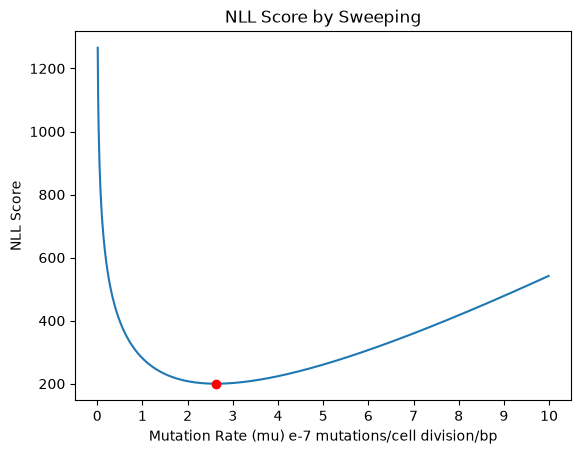

In [7]:
mu_candidates = np.arange(0.01, 10, 0.01).tolist()

scores_nll_ = [0.0] * len(mu_candidates)

for i in range(len(mu_candidates)):
  total = 0
  for j in range(len(lineages)):
    total += nll(lineages[j], mu_candidates[i]*(genome_size_lineages[j])*10**(-7))
  scores_nll_[i] = total

position_of_min_nll = position_of_min(scores_nll_)
mu_hat = mu_candidates[position_of_min_nll]
print(f"Estimated mutation rate (mu_hat): {mu_hat} e-7 mutations/cell division/bp")

fig, ax = plt.subplots()
ax.plot(mu_candidates, scores_nll_)
ax.plot(mu_hat, scores_nll_[position_of_min_nll], 'ro')
ax.set_xlabel("Mutation Rate (mu) e-7 mutations/cell division/bp")
ax.set_ylabel("NLL Score")
ax.set_title("NLL Score by Sweeping")
ax.set_xticks(range(11))
plt.show()

#### Fitted parameter plot

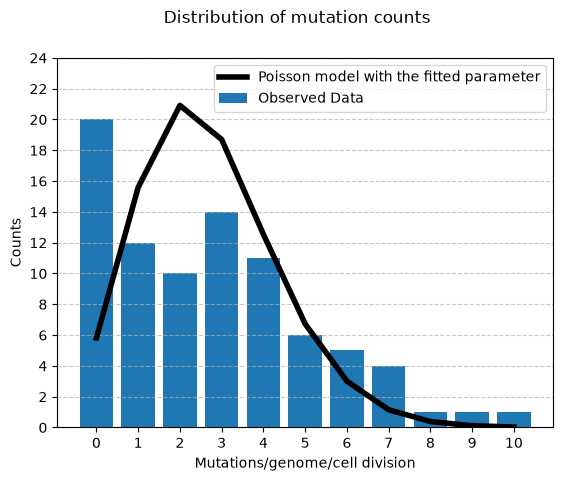

In [8]:
k_counts = list(range(max_mutation_count + 1))
y = [0] * len(k_counts)
for i in range(len(k_counts)):
    y[i] += poisson(k_counts[i], mu_hat*genome_size*10**(-7))

y = [n * sample_size for n in y]

fig, ax = plt.subplots()
ax.plot(k_counts, y, color="black", label="Poisson model with the fitted parameter",linewidth=4)
ax.bar(range(len(mutation_counts)), mutation_counts, label="Observed Data")
ax.set_xlabel("Mutations/genome/cell division")
ax.set_ylabel("Counts")
ax.set_xticks(range(0,11))
ax.set_yticks(range(0,25,2))
ax.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
fig.suptitle("Distribution of mutation counts")
ax.legend();

### Parameter Uncertainty

#### Likelihood Interval

$$\{\theta : \mathrm{NLL}(\theta) \le \mathrm{NLL}(\hat{\theta}) + \tfrac{1}{2}\}$$

In [9]:
low = mu_hat
high = mu_hat

for j in range(len(mu_candidates)):
  if scores_nll_[j] <= scores_nll_[position_of_min_nll] + 0.5:
    if mu_candidates[j] < low:
      low = mu_candidates[j]
    elif mu_candidates[j] > high:
      high = mu_candidates[j]


print("likelihood interval:", low, "to", high, "e-7 mutations per division per base pair, half-width", round((high - low) / 2, 3))


likelihood interval: 2.46 to 2.8 e-7 mutations per division per base pair, half-width 0.17


#### Bootstrap

In [10]:
N = 85
B = 2000
SEED = 26546
rs = uniforms(B * N, SEED)
equal = [1 / N] * N

boot_estimates = [0.0] * B
for b in range(B):
  resample = [0.0] * N
  for i in range(N):
    j = choose(rs[b*N + i], equal)
    resample[i] = counts[j]
  boot_estimates[b] = mean(resample)

sigma_boot = std_dev(boot_estimates)
print(f"Bootstrap estimate of standard error: {round(sigma_boot, 3)} mutations/genome/cell division")

Bootstrap estimate of standard error: 0.254 mutations/genome/cell division


## 2-Poisson Model

### Forwards Simulation

σ² (Simulation): 5.36251288926016 (mutations/cell division)² 
σ² (Reported Data): 5.721245674740486 (mutations/cell division)²
Zero Count (Simulation) 20.96 
Zero Count (Reported Data) 20


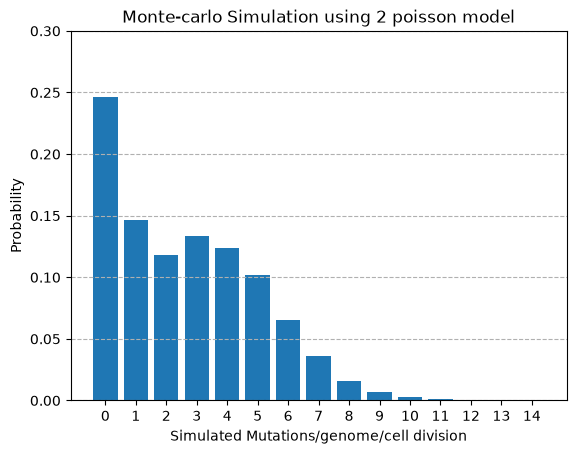

In [11]:
state = seed

simulated_runs_twoP = []
sim_twoP_devs = []
sim_twoP_zeros = []
sim_twoP_sums = []

for i in range(100):
    simulated_counts, state = experiment_twoP(rprt_two_poisson_pi,rprt_two_poisson_lam_low, rprt_two_poisson_lam_high, sample_size, state)
    simulated_runs_twoP.append(simulated_counts)
    sim_twoP_devs.append(std_dev(simulated_counts))
    sim_twoP_zeros.append(fraction_zero(simulated_counts) * 85)
    sim_twoP_sums.append(sum(simulated_counts))

print(f"σ² (Simulation): {mean(sim_twoP_devs) ** 2} (mutations/cell division)² \nσ² (Reported Data): {sample_variance} (mutations/cell division)²")
print(f"Zero Count (Simulation) {mean(sim_twoP_zeros)} \nZero Count (Reported Data) {sample_zeros}")

fig_2p, ax = plt.subplots()
simulated_runs_twoP_flat = [y for x in simulated_runs_twoP for y in x]

simulated_twoP_mutation_counts = [0] * (max(simulated_runs_twoP_flat) + 1)

for count in simulated_runs_twoP_flat:
    simulated_twoP_mutation_counts[count] += 1 

simulated_twoP_mutation_probs = [x/sum(simulated_twoP_mutation_counts) for x in simulated_twoP_mutation_counts]

ax.bar(range(len(simulated_twoP_mutation_probs)), simulated_twoP_mutation_probs)
ax.set_title("Monte-carlo Simulation using 2 poisson model")
ax.set_xlabel("Simulated Mutations/genome/cell division")
ax.set_ylabel("Probability")
ax.grid(axis="y", linestyle="--")
ax.set_xticks((range(min(simulated_runs_twoP_flat), max(simulated_runs_twoP_flat)+1, 1)));
ax.set_ylim(0,0.3);

### Backwards Estimation

$$\hat{\lambda_{low}}, \hat{\lambda_{low}}, \hat{\pi} = \arg\min_{\lambda_{low}, \lambda_{low}, \pi} \mathrm{NLL}(\lambda_{low}, \lambda_{low}, \pi), \qquad \mathrm{NLL}(\lambda_{low}, \lambda_{high}, \pi) = -\sum_{i=1}^{N} \ln p(x_i \mid \lambda_{low}, \lambda_{high}, \pi)


In [15]:
mu_low_candidates = np.arange(0, 2, 0.02).tolist()
mu_high_candidates = np.arange(1 , 5, 0.02).tolist()
pi_candidates = np.arange(0.05 , 0.95, 0.02).tolist()

scores_2P, best_scores_2P_param, best_scores_2P = fit_2_poisson(counts, mu_low_candidates, mu_high_candidates, pi_candidates)
mu_low_hat, mu_high_hat, pi_hat = best_scores_2P
best_scores_mu_low, best_scores_mu_high, best_scores_pi = best_scores_2P_param

best_score_2P = scores_2P[position_of_min(scores_2P)]

reported_mu_low = 0.4e-7
reported_mu_high = 4.0e-7
reported_pi = 35.0
header_format = "{:<15} | {:>20} | {:>20}"
row_format = "{:<15} | {:>20} | {:>20}"

print("-" * 61)
print(header_format.format("Parameter", "Estimated Value", "Reported Value"))
print("-" * 61)
print(row_format.format("mu_low", f"{mu_low_hat*10}e-08", f"{reported_mu_low}"))
print(row_format.format("mu_high", f"{mu_high_hat}e-07", f"{reported_mu_high}"))
print(row_format.format("pi", f"{pi_hat*100}%", f"{reported_pi}%"))
print("-" * 61)

-------------------------------------------------------------
Parameter       |      Estimated Value |       Reported Value
-------------------------------------------------------------
mu_low          |              4.4e-08 |                4e-08
mu_high         |              3.8e-07 |                4e-07
pi              |                35.0% |                35.0%
-------------------------------------------------------------


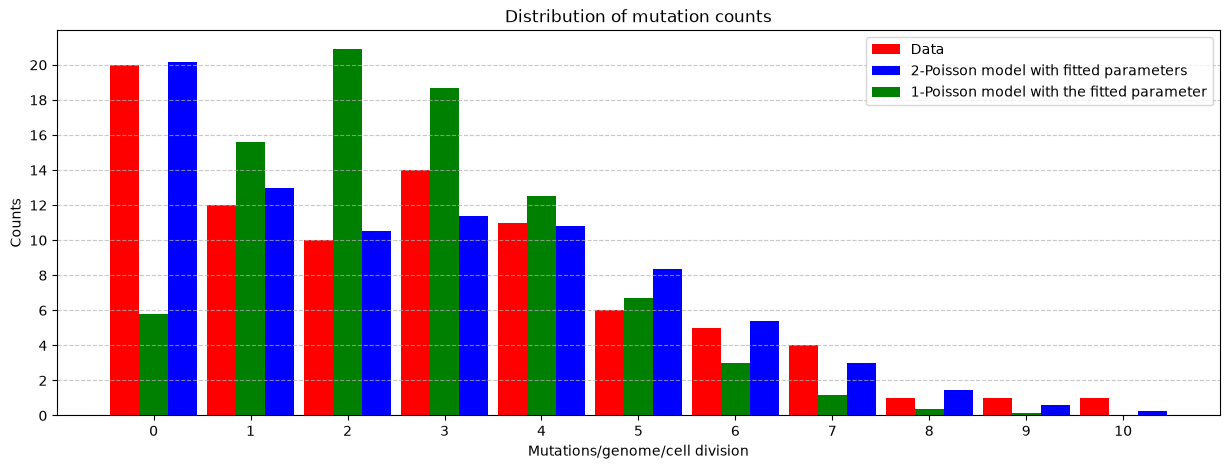

In [16]:
y_mix_poisson_lik = [0] * len(counts)


for i in range(len(counts)):
    y_mix_poisson_lik[i] += two_poisson(counts[i], pi_hat, mu_low_hat*genome_size*10**(-7), mu_high_hat*genome_size*10**(-7))

y_mix_poisson_lik = [x * sample_size for x in y_mix_poisson_lik]


plt.figure(figsize=(15, 5))
plt.bar(np.array(range((max_mutation_count)+1)) - 0.3, mutation_counts, width=0.3, label='Data', color='red')
plt.bar(np.array(counts) + 0.3, y_mix_poisson_lik, width=0.3, label='2-Poisson model with fitted parameters', color='blue')
plt.bar(np.array(k_counts), y,color="green", label="1-Poisson model with the fitted parameter", width=0.3)
plt.xlabel("Mutations/genome/cell division")
plt.ylabel("Counts")
plt.xticks(range(0,11));
plt.yticks(range(0,22,2));
plt.grid(axis='y', linestyle='--', alpha=0.7, zorder=0)
plt.title("Distribution of mutation counts")
plt.legend()
plt.show()

### Parameter Uncertainty

#### Likelihood Interval

For every candidate of a parameter the best scoring combination with other parameters is recorded. The likelihood interval around the best scoring candidate

In [ ]:
mu_low_low, mu_low_high = param_interval(mu_low_candidates, best_scores_mu_low, position_of_min(best_scores_mu_low))
mu_high_low, mu_high_high = param_interval(mu_high_candidates, best_scores_mu_high, position_of_min(best_scores_mu_high))
pi_low, pi_high = param_interval(pi_candidates, best_scores_pi, position_of_min(best_scores_pi))

print("Best mu_low:", mu_low_hat)
print("likelihood interval:", mu_low_low, "to", mu_low_high, "e-07 mutations per division per base pair, half-width", round((mu_low_high - mu_low_low) / 2, 3))

print("Best mu_high:", mu_high_hat)
print("likelihood interval:", mu_high_low, "to", mu_high_high, "e-07 mutations per division per base pair, half-width", round((mu_high_high - mu_high_low) / 2, 3))

print("Best pi:", pi_hat)
print("likelihood interval:", pi_low, "to", pi_high, round((pi_high - pi_low) / 2, 3))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for mu_low in best_scores_mu_low:
    axes[0].plot(mu_low_candidates, best_scores_mu_low, color='blue')
    axes[0].set_xlabel("mu_low candidates")
    axes[0].set_ylabel("NLL Score")
    axes[0].set_title("NLL Score vs mu_low candidates")
    axes[0].plot(mu_low_hat, best_scores_mu_low[position_of_min(best_scores_mu_low)], 'ro')
    
for mu_high in best_scores_mu_high:
    axes[1].plot(mu_high_candidates, best_scores_mu_high, color='blue')
    axes[1].set_xlabel("mu_high candidates")
    axes[1].set_ylabel("NLL Score")
    axes[1].set_title("NLL Score vs mu_high candidates")
    axes[1].plot(mu_high_hat, best_scores_mu_high[position_of_min(best_scores_mu_high)], 'ro')
    
for pi in best_scores_pi:
    axes[2].plot(pi_candidates, best_scores_pi, color='blue')
    axes[2].set_xlabel("pi candidates")
    axes[2].set_ylabel("NLL Score")
    axes[2].set_title("NLL Score vs pi candidates")
    axes[2].plot(pi_hat, best_scores_pi[position_of_min(best_scores_pi)], 'ro')


# Model Comparison

We compare both models when the genome size of individual lineages were taken into account.

In [ ]:
AIC_1_Poisson = 2 * 1 + 2 * scores_nll_[position_of_min_nll]
AIC_2_Poisson = 2 * 3 + 2 * best_score_2P
print("AIC for 1-Poisson model:", round(AIC_1_Poisson,2))
print("AIC for 2-Poisson model:", round(AIC_2_Poisson,2))

### Discussion

- The Poisson model is biologically plausible because it describes the number of rare mutation events occurring during a fixed cell division. Each cell division is one observation and the number of newly fixed mutations is the random variable.

- A single Poisson assumes that all cell divisions have the same mutation rate. However, the data show strong overdispersion, meaning that the variability is larger than expected under a single Poisson distribution. The two-Poisson mixture provides a biological explanation for this heterogeneity by modelling two mutator phenotypes: a hypomutator population with a low mutation rate and a hypermutator population with a high mutation rate. Therefore, the mixture is not only a better-fitting curve but represents a plausible alternative mechanism for generating the observed data.

- The simulation results show that the two-Poisson model fits the reported data much better than the single Poisson model. For the variance (σ²), the single Poisson simulation produced a value of 2.64, which is far from the reported 5.72, while the Two-Poisson simulation yielded 5.42, much closer to the reported value. Similarly, the zero count in the single Poisson simulation was 6.29, far below the reported 20, whereas the Two-Poisson simulation gave 21.09, nearly matching the reported value.

- The two-Poisson model performed better than the single-Poisson model, with AIC values of 365.11 and 402.12, respectively. The lower AIC supports the additional complexity of the mixture model. The simulations also showed that the two-Poisson model reproduces the observed distribution more closely.

- The estimated mutation rates were approximately 4.4e-8 and 3.8e-7 mutations/bp/cell division, with 35% of observations assigned to the low-mutation population. These values are close to those reported in the paper: 4e-8 and 4e-7 mutations/bp/cell division and 35% for the hypomutator population. This agreement provides a useful check that our fitting procedure produces biologically consistent parameter estimates.

- Parameter uncertainty was explored using uncertainty estimates from the fitted models and by simulation. For the single-Poisson model, we used bootstrap resampling to estimate the uncertainty of the parameter because this model is known to be an incomplete description of the data. Bootstrap is appropriate here because it estimates variability directly from the observed data without requiring the single-Poisson model to be correct.